In [ ]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [ ]:
# veriyi gor
veri = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/medical_insurance.csv")
veri.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [ ]:
# eksik deger var mi bak
veri.isna().sum()

,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [ ]:
# dtyplara bak
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [ ]:
# alkol verisi nerdeyse yuzde 40 i yok onu at ayrica id ise yaramaz onuda at daha sonra degerlere bak
veri = veri.drop(["alcohol_freq","person_id"], axis=1, errors="ignore")
veri.describe()

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [ ]:
# outlier temizligi icin sayisal sutunlari aldik outlier i donguyle temizledik
num_cols = veri.select_dtypes(include=("float64","int64")).columns
for col in num_cols:
    Q1 = veri[col].quantile(0.02)
    Q3 = veri[col].quantile(0.98)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = veri[(veri[col] < lower) | (veri[col] > upper)]
    print(f"{col} sütununda {len(outliers)} adet aykırı değer vardır.")
    veri_no_outliers = veri.copy()
    veri_no_outliers = veri_no_outliers[(veri_no_outliers[col] >= lower) & (veri_no_outliers[col] <= upper)]

person_id sütununda 0 adet aykırı değer vardır.
age sütununda 0 adet aykırı değer vardır.
income sütununda 69 adet aykırı değer vardır.
household_size sütununda 0 adet aykırı değer vardır.
dependents sütununda 0 adet aykırı değer vardır.
bmi sütununda 0 adet aykırı değer vardır.
visits_last_year sütununda 7 adet aykırı değer vardır.
hospitalizations_last_3yrs sütununda 8 adet aykırı değer vardır.
days_hospitalized_last_3yrs sütununda 2 adet aykırı değer vardır.
medication_count sütununda 1 adet aykırı değer vardır.
systolic_bp sütununda 0 adet aykırı değer vardır.
diastolic_bp sütununda 0 adet aykırı değer vardır.
ldl sütununda 0 adet aykırı değer vardır.
hba1c sütununda 0 adet aykırı değer vardır.
deductible sütununda 0 adet aykırı değer vardır.
copay sütununda 0 adet aykırı değer vardır.
policy_term_years sütununda 0 adet aykırı değer vardır.
policy_changes_last_2yrs sütununda 0 adet aykırı değer vardır.
provider_quality sütununda 0 adet aykırı değer vardır.
risk_score sütununda 0 ad

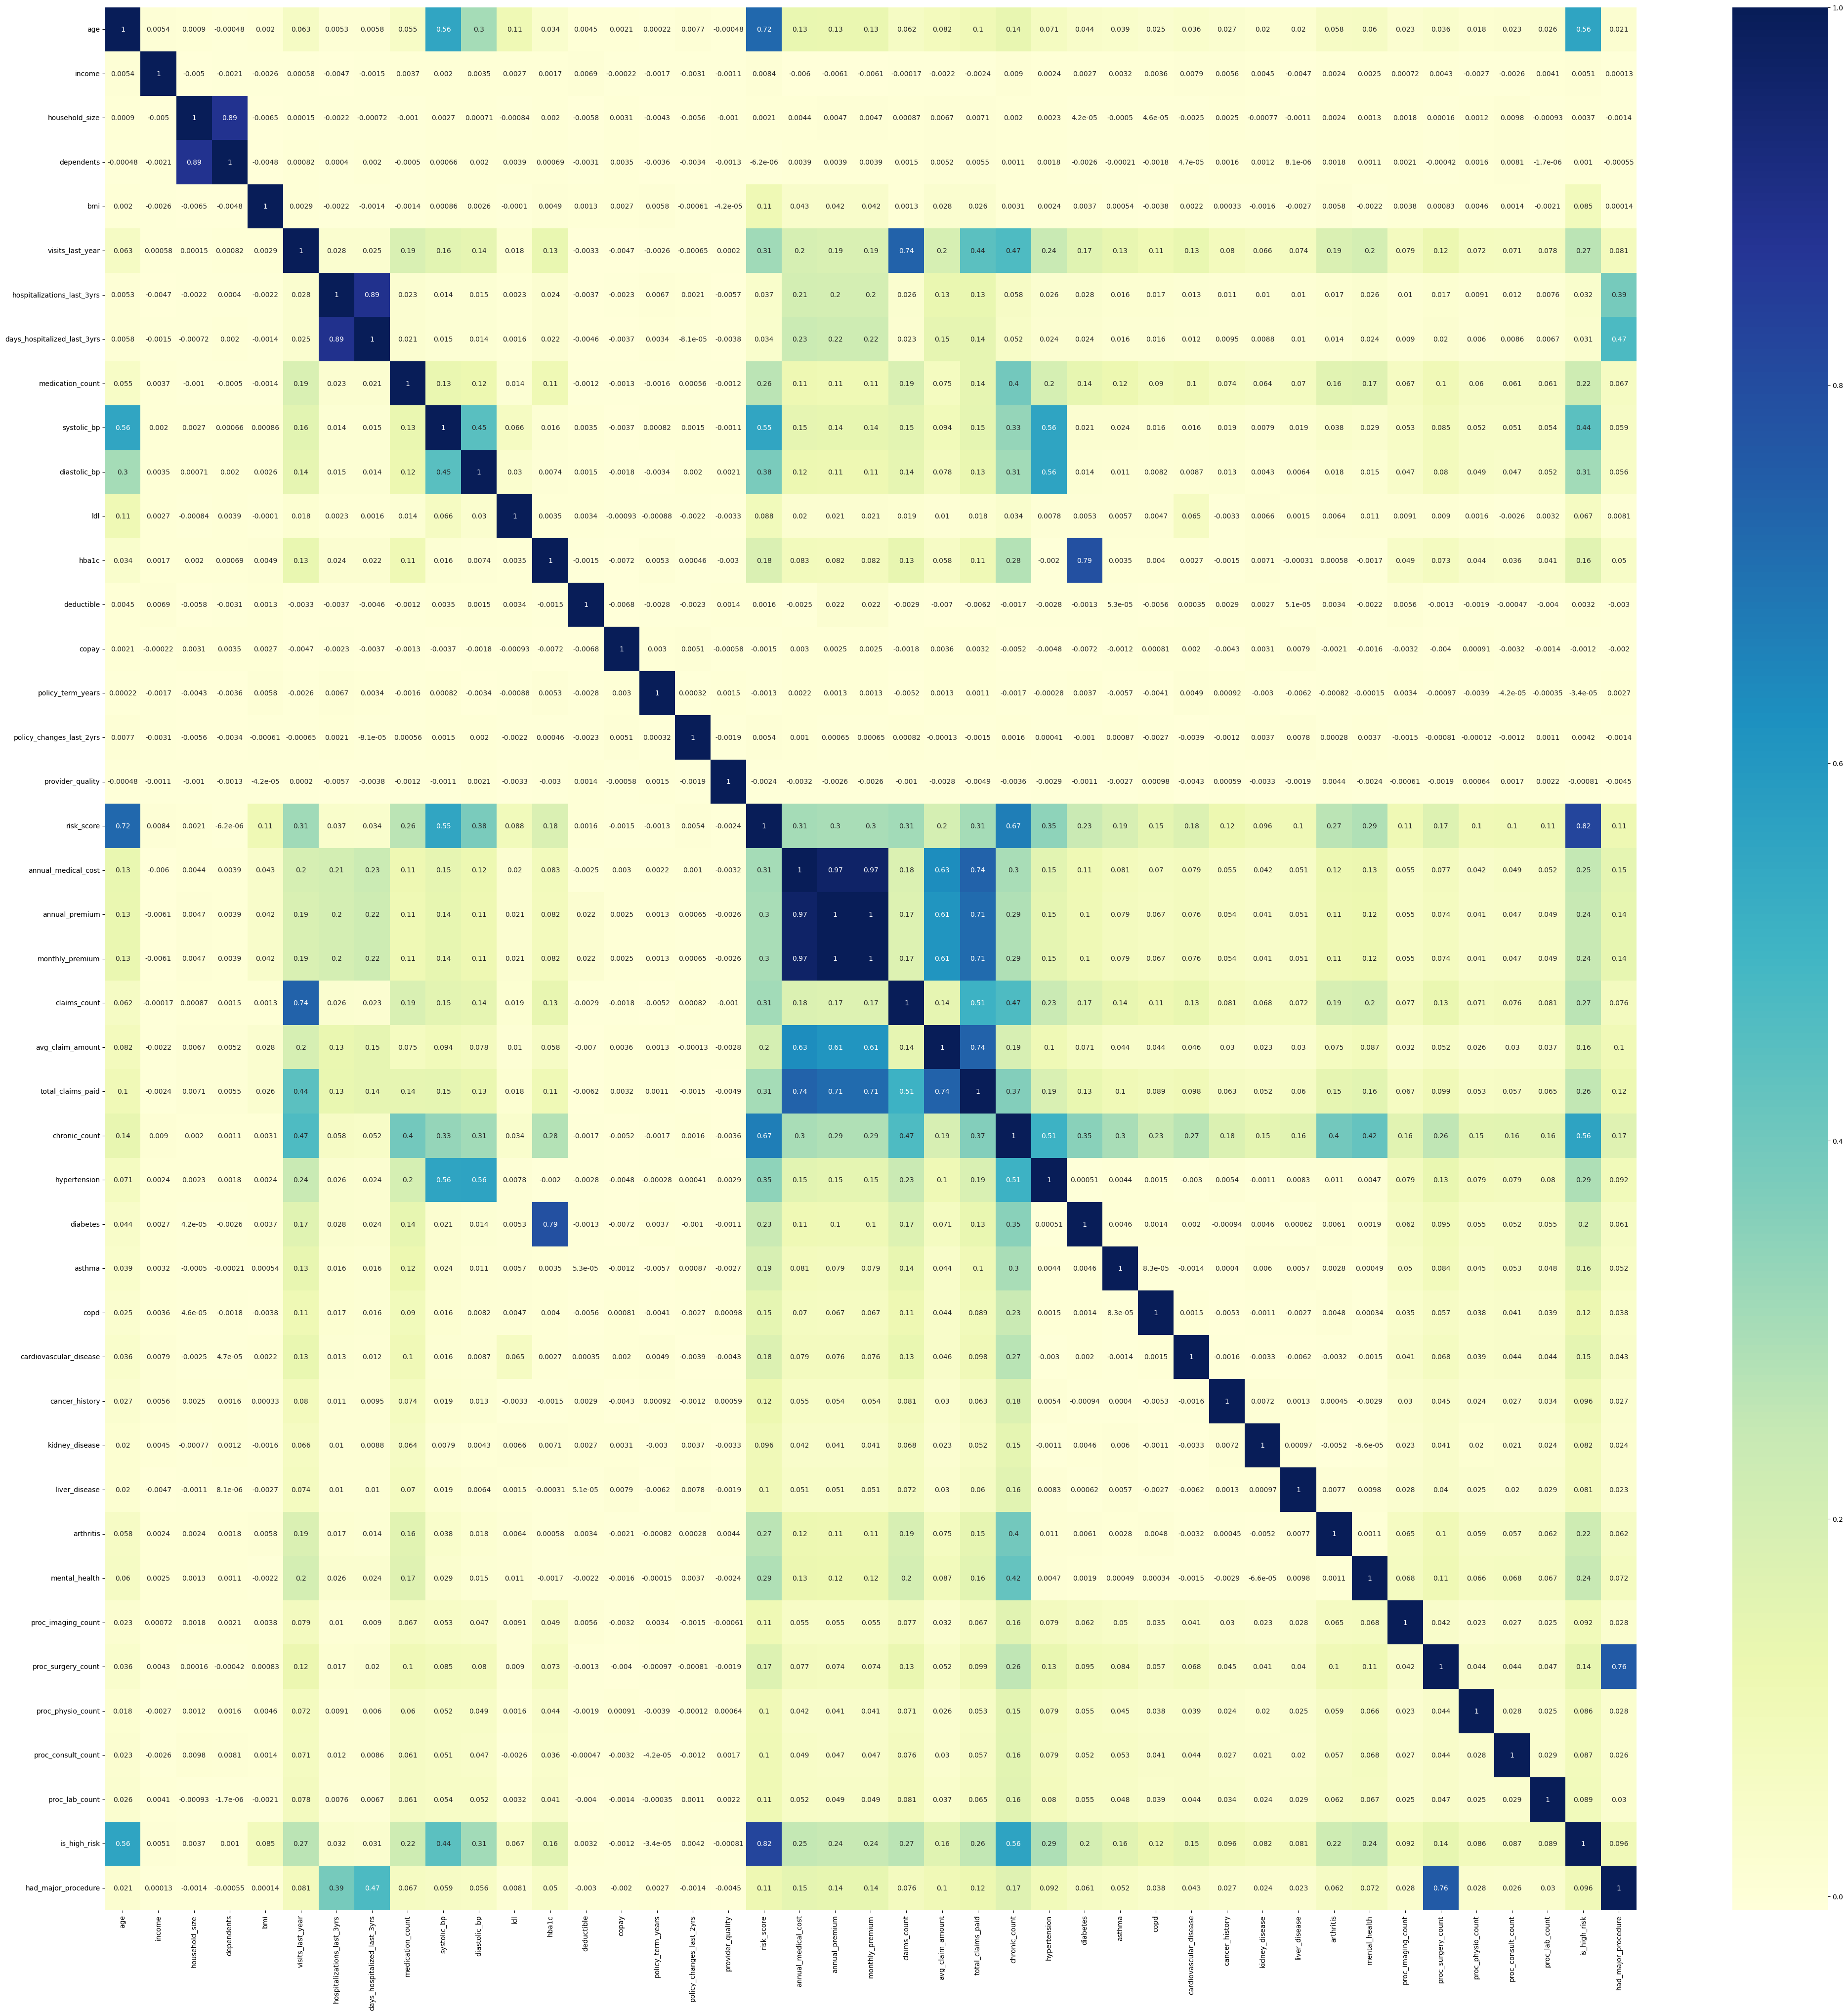

In [ ]:
# corr hesapladik ve bunu isi haritasinda gosterdik
corr_matrix = veri[num_cols].corr()
plt.figure(figsize=(50,50))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu")
plt.show()

<Axes: >

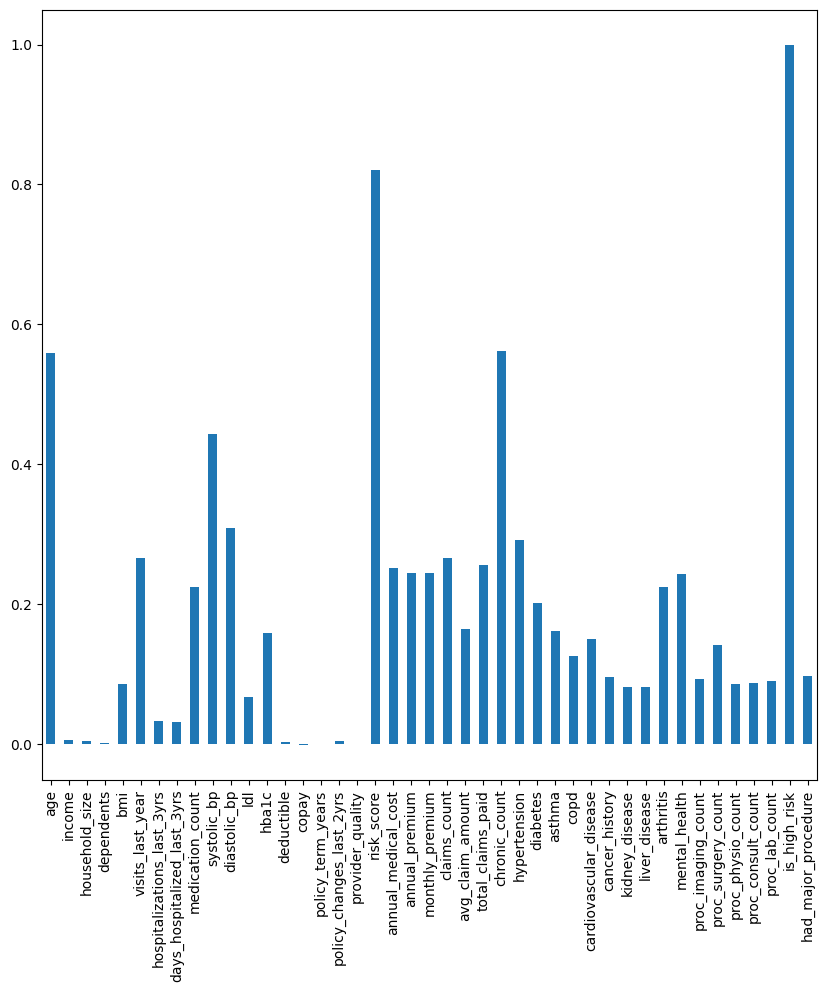

In [ ]:
# ilk target icin spesifik korelasyon baktik
corr_matrix["is_high_risk"].plot.bar(figsize=(10,10))

<Axes: >

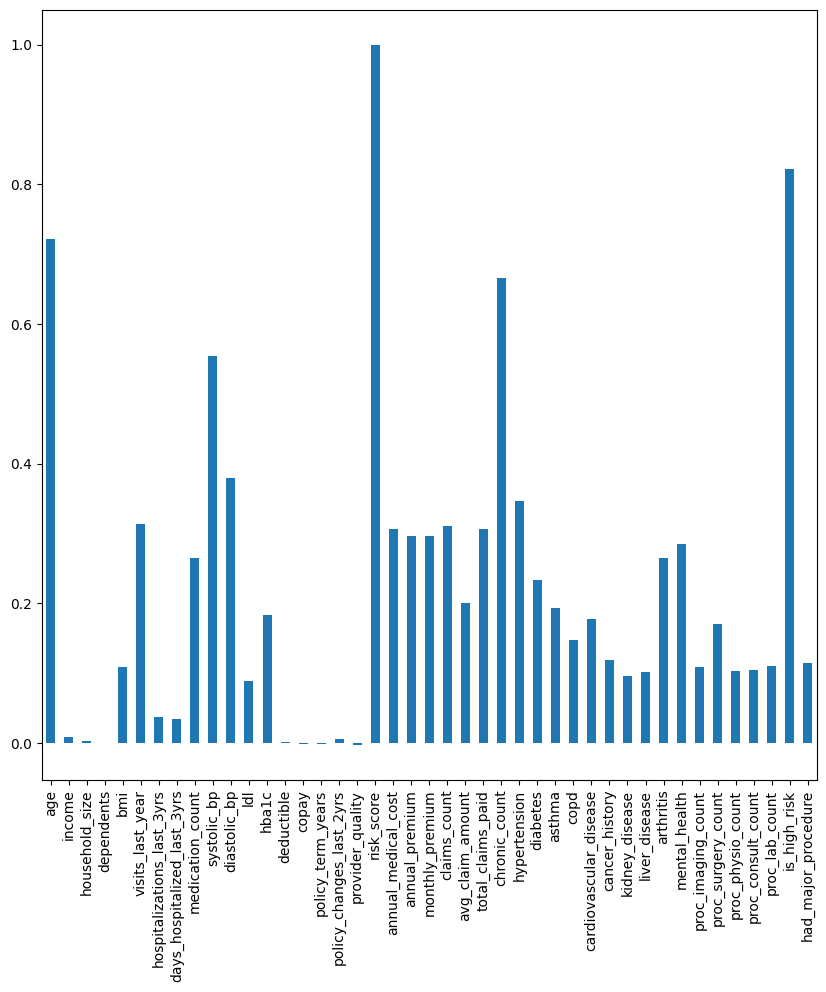

In [ ]:
# 2.target icin spesifik korelasyon baktik
corr_matrix["risk_score"].plot.bar(figsize=(10,10))

In [ ]:
  # verilerimizi ayiriyoruz ml icin is_high_risk ve risk_score birbirleriyle fazla iliskili oldugu icin ikisinide cikarmamiz gerekli
  X = veri.drop(["is_high_risk","risk_score"], axis=1)
  y = veri["is_high_risk"]

In [ ]:
# classification icin bir fonksiyon olusturduk zaman ve kod tasarrufu olusturuldu
def skor_hesapla(veri, model, X, y):

  # X deki stringleri sayisal forma cevirme islemi yapiyoruz
  obj_cols = veri.select_dtypes(include="object").columns
  one_hot = OneHotEncoder()
  transformer = ColumnTransformer([("one_hot", one_hot, obj_cols)], remainder="passthrough")
  transformed_X = transformer.fit_transform(X)

  # train ve test datalarimizi ayiriyoruz
  X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2, random_state=42)

  # iki model ile verilerimizi egitip skor alicaz
  model.fit(X_train, y_train)

  # tahminleri aliyoruz skor icin
  y_preds = model.predict(X_test)

  # skorlarimizi aliyoruz
  acc = accuracy_score(y_test, y_preds)
  prec = precision_score(y_test, y_preds)
  rec = recall_score(y_test, y_preds)
  cnfmtrx = confusion_matrix(y_test, y_preds)

  print(f"Accuracy: {acc}")
  print(f"Precision: {prec}")
  print(f"Recall: {rec}")
  print(f"Confusion Matrix:\n{cnfmtrx}")

In [ ]:
skor_hesapla(veri=veri, model=RandomForestClassifier(), X=X, y=y)

Accuracy: 0.99055
Precision: 0.989148128052089
Recall: 0.9852722605053371
Confusion Matrix:
[[12519    80]
 [  109  7292]]


In [ ]:
skor_hesapla(veri=veri_no_outliers, model=RandomForestClassifier(), X=X, y=y)

Accuracy: 0.9907
Precision: 0.9898167006109979
Recall: 0.9850020267531414
Confusion Matrix:
[[12524    75]
 [  111  7290]]


In [ ]:
skor_hesapla(veri=veri, model=LogisticRegression(), X=X, y=y)

Accuracy: 0.75055
Precision: 0.6816265060240964
Recall: 0.6115389812187543
Confusion Matrix:
[[10485  2114]
 [ 2875  4526]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
skor_hesapla(veri=veri_no_outliers, model=LogisticRegression(), X=X, y=y)


Accuracy: 0.75055
Precision: 0.6816265060240964
Recall: 0.6115389812187543
Confusion Matrix:
[[10485  2114]
 [ 2875  4526]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Regression icin fonksiyon olusturuldu
def skor_hesapla_2(veri, model, X, y):

  # X deki stringleri sayisal forma cevirme islemi yapiyoruz
  obj_cols = veri.select_dtypes(include="object").columns
  one_hot = OneHotEncoder()
  transformer = ColumnTransformer([("one_hot", one_hot, obj_cols)], remainder="passthrough")
  transformed_X = transformer.fit_transform(X)

  # train ve test datalarimizi ayiriyoruz
  X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2, random_state=42)

  # iki model ile verilerimizi egitip skor alicaz
  model.fit(X_train, y_train)

  # skorlarimizi aliyoruz
  r2 = r2_score(y_test, model.predict(X_test))
  mae = mean_absolute_error(y_test, model.predict(X_test))
  mse = mean_squared_error(y_test, model.predict(X_test))

  print(f"R2 Score: {r2}")
  print(f"Mean Absolute Error: {mae}")
  print(f"Mean Squared Error: {mse}")

In [ ]:
  # verilerimizi ayiriyoruz ml icin
  X = veri.drop(["is_high_risk","risk_score"], axis=1)
  y = veri["risk_score"]

In [ ]:
skor_hesapla_2(veri=veri, model=RandomForestRegressor(), X=X, y=y)

R2 Score: 0.9999696536003557
Mean Absolute Error: 7.759555000072661e-05
Mean Squared Error: 1.9101946159499983e-06


In [ ]:
veri.corr()["risk_score"].sort_values(ascending=False).head(10)


ValueError: could not convert string to float: 'Female'

In [ ]:
skor_hesapla_2(veri=veri_no_outliers, model=RandomForestRegressor(), X=X, y=y)

KeyboardInterrupt: 

In [ ]:
sko